# 5. Análisis de Redes Sociales con NetworkX

### (a) Cargar un grafo de red social predefinido (Karate Club)

In [5]:
import networkx as nx
import matplotlib.pyplot as plt


G = nx.karate_club_graph()
print("Grafo cargado exitosamente.")

Grafo cargado exitosamente.


### (b) Exploración Básica del Grafo
Extracción del número total de nodos (usuarios) y aristas (conexiones), y visualización inicial de la red.

Número de nodos: 34
Número de aristas: 78


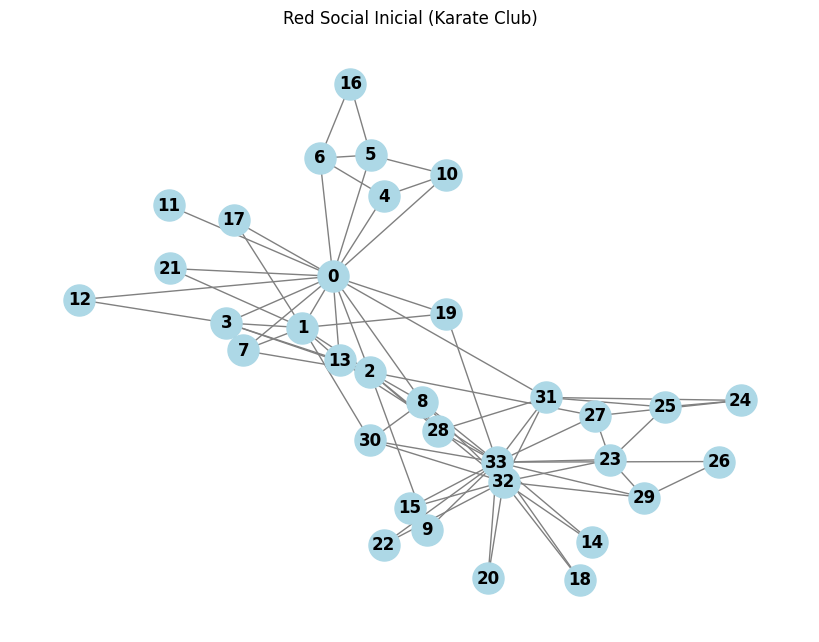

In [6]:
num_nodos = G.number_of_nodes()
num_aristas = G.number_of_edges()

print(f"Número de nodos: {num_nodos}")
print(f"Número de aristas: {num_aristas}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) 
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_weight='bold', edge_color='gray')
plt.title("Red Social Inicial (Karate Club)")
plt.show()

### (c) Definición de "Influencer"
Proponemos tres métricas de centralidad:

1. **Centralidad de Grado (Degree):** Quien tiene más conexiones directas.
2. **Centralidad de Intermediación (Betweenness):** Quien actúa como puente principal entre diferentes grupos.
3. **Centralidad de Cercanía (Closeness):** Quien puede alcanzar a todos los demás en la menor cantidad de pasos.

Influencer por Grado: Nodo 33
Influencer por Intermediación: Nodo 0
Influencer por Cercanía: Nodo 0


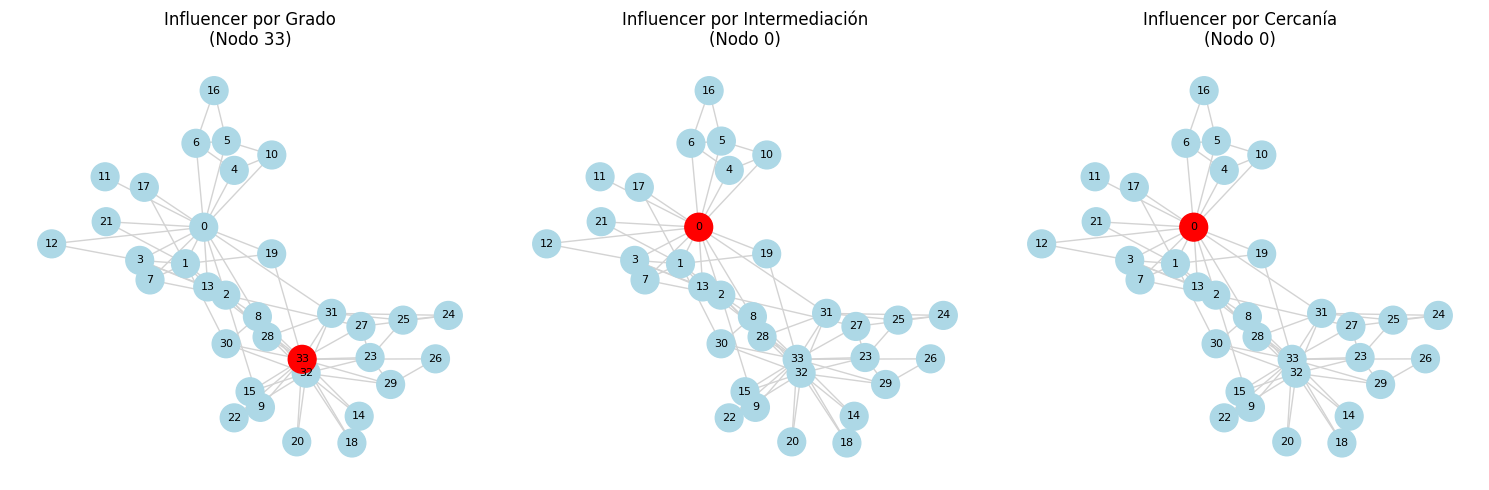

In [7]:
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)

top_degree = max(degree_cent, key=degree_cent.get)
top_betweenness = max(betweenness_cent, key=betweenness_cent.get)
top_closeness = max(closeness_cent, key=closeness_cent.get)

print(f"Influencer por Grado: Nodo {top_degree}")
print(f"Influencer por Intermediación: Nodo {top_betweenness}")
print(f"Influencer por Cercanía: Nodo {top_closeness}")

plt.figure(figsize=(15, 5))

def plot_influencer(subplot_idx, metric_name, top_node):
    plt.subplot(1, 3, subplot_idx)
    color_map = ['red' if node == top_node else 'lightblue' for node in G]
    nx.draw(G, pos, with_labels=True, node_color=color_map, 
            node_size=400, font_size=8, edge_color='lightgray')
    plt.title(f"{metric_name}\n(Nodo {top_node})")

plot_influencer(1, "Influencer por Grado", top_degree)
plot_influencer(2, "Influencer por Intermediación", top_betweenness)
plot_influencer(3, "Influencer por Cercanía", top_closeness)

plt.tight_layout()
plt.show()

### (e) Identificación de Comunidades
Utilizamos el algoritmo de Louvain o de partición codiciosa, el cual busca agrupar los nodos maximizando la densidad de conexiones internas (modularidad) frente a las conexiones externas.

In [8]:
from networkx.algorithms.community import louvain_communities

comunidades = list(louvain_communities(G, seed=42))
print(f"Total de comunidades encontradas: {len(comunidades)}\n")

for i, comunidad in enumerate(comunidades):
    tamaño = len(comunidad)
    
    if tamaño == 3:
        categoria = "Tamaño 3"
    elif tamaño == 4:
        categoria = "Tamaño 4"
    elif tamaño >= 5:
        categoria = "Tamaño 5 o más"
    else:
        categoria = "Menos de 3"
        
    print(f"Comunidad {i+1} ({categoria}):")
    print(f" - Integrantes: {sorted(list(comunidad))}")
    print(f" - Total de nodos: {tamaño}\n")

Total de comunidades encontradas: 4

Comunidad 1 (Tamaño 5 o más):
 - Integrantes: [1, 2, 3, 7, 12, 13]
 - Total de nodos: 6

Comunidad 2 (Tamaño 5 o más):
 - Integrantes: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
 - Total de nodos: 10

Comunidad 3 (Tamaño 4):
 - Integrantes: [24, 25, 28, 31]
 - Total de nodos: 4

Comunidad 4 (Tamaño 5 o más):
 - Integrantes: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
 - Total de nodos: 14

